## Klasterovanje

k-means -> izmerimo koliko su tacke udaljene od nekog centroida => najbliza pripada njemu (centroid je jedan klaster)

In [2]:
import pandas as pd

minmaxscaler => $ \frac{X-Xmin}{Xmax-Xmin}$

In [3]:
from sklearn.preprocessing import MinMaxScaler

In [4]:
data = pd.read_csv('./data/dogs.csv')
data

,breed,height,weight
0,Border Collie,20,45
1,Boston Terrier,16,20
2,Brittany Spaniel,18,35
3,Bullmastiff,27,120
4,Chihuahua,8,8
5,German Shepherd,25,78
6,Golden Retriever,23,70
7,Great Dane,32,160
8,Portuguese Water Dog,21,50
9,Standard Poodle,19,65


In [8]:
scaler = MinMaxScaler()

In [16]:
feature_names = data.columns[1:]
feature_names

Index(['height', 'weight'], dtype='object')

In [17]:
X = data[feature_names]

In [18]:
X = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

In [19]:
X

,height,weight
0,0.538462,0.248366
1,0.384615,0.084967
2,0.461538,0.183007
3,0.807692,0.738562
4,0.076923,0.006536
5,0.730769,0.464052
6,0.653846,0.411765
7,1.000000,1.000000
8,0.576923,0.281046
9,0.500000,0.379085


In [20]:
from sklearn.cluster import KMeans

In [22]:
model = KMeans(n_clusters=2)

In [23]:
model.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [24]:
model.labels_

array([1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0], dtype=int32)

In [27]:
from matplotlib import pyplot as plt

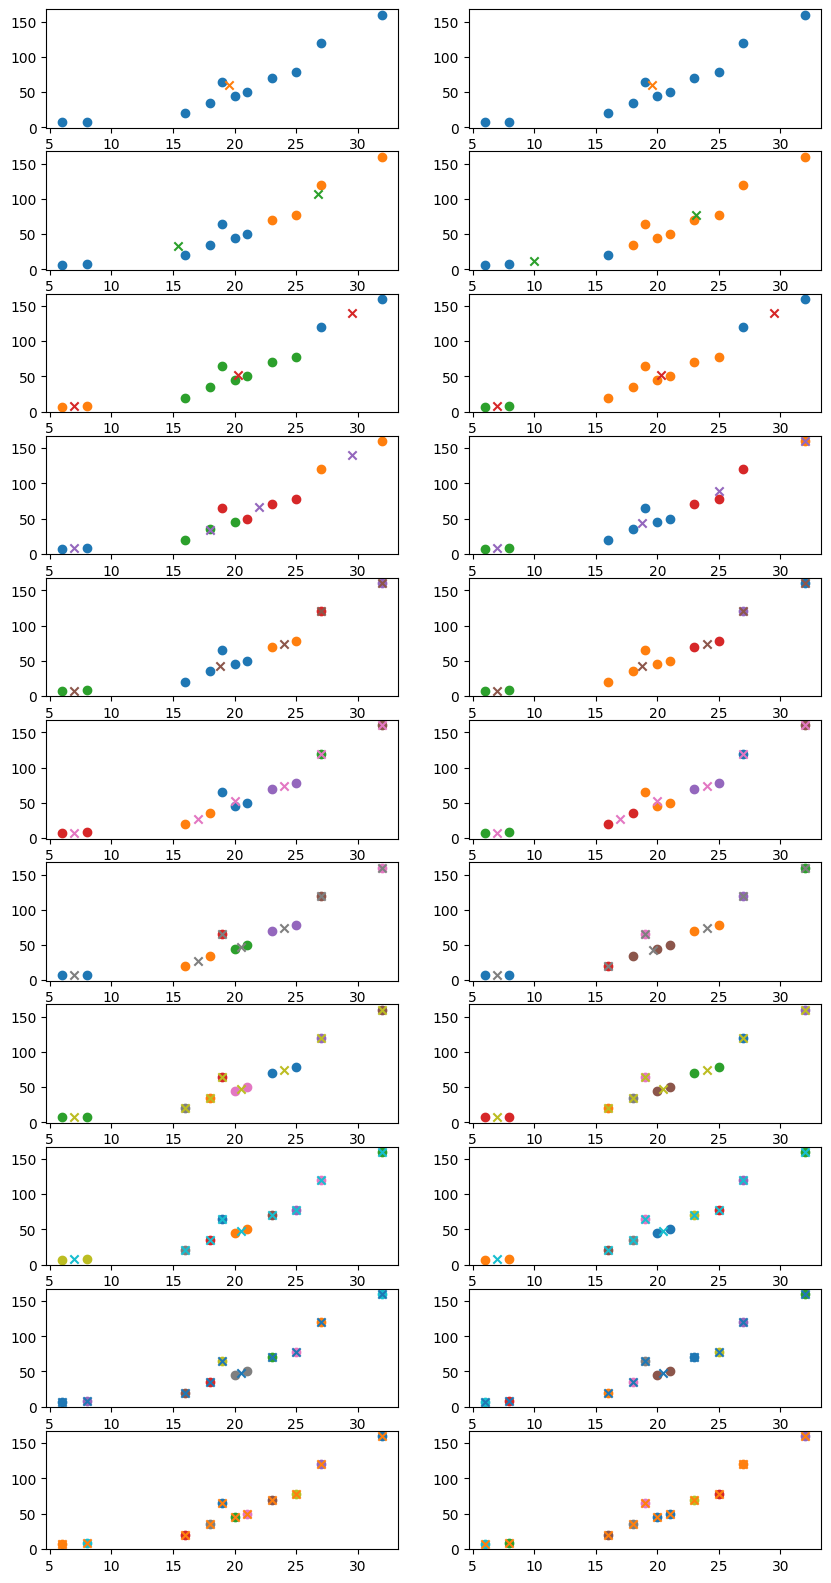

In [40]:
ks = range(1, X.shape[0] + 1)
inits = ['random', 'k-means++']
fig = plt.figure(figsize=(10,20))
idx = 1
inertias = []
for k in ks:
    for init in inits:
        model = KMeans(n_clusters=k, init=init)
        model.fit(X)

        if init == 'k-means++':
            inertias.append(model.inertia_)

        fig.add_subplot(len(ks), len(inits), idx)
        idx += 1
        for cluster_label in range(k):
            cluster = data[model.labels_ == cluster_label]
            plt.scatter(cluster['height'], cluster['weight'])

        centroids = pd.DataFrame(scaler.inverse_transform(model.cluster_centers_), columns=feature_names)
        plt.scatter(centroids['height'], centroids['weight'], marker='x')

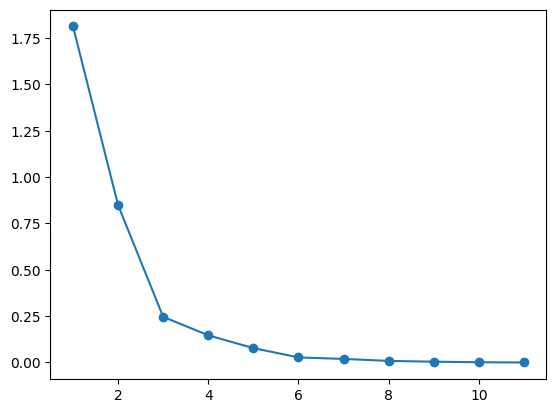

In [41]:
plt.plot(ks, inertias, marker='o')
plt.show()

In [42]:
from sklearn.cluster import AgglomerativeClustering